<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/naming_colors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green?

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'munsell-array-fixed-choice.csv'.

from google.colab import files
uploaded = files.upload()

Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

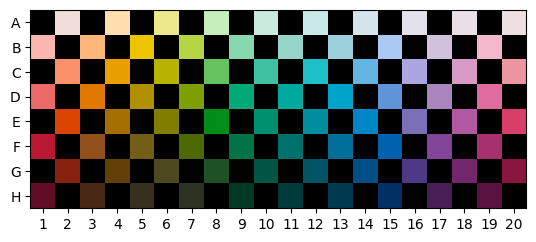

In [3]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

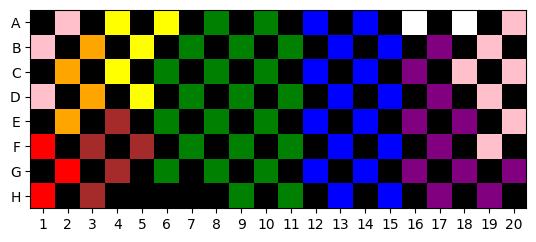

In [4]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


In [7]:
# For each language, calculate what percentage of chips are named each color. Return dataframes for each language.
def calcular_porcentajes(columna_idioma):
    # Contamos cuántas veces aparece cada nombre de color
    conteo = df[columna_idioma].value_counts()
    # Convertimos a porcentaje (total de chips = 80)
    porcentaje = (conteo / len(df)) * 100
    # Retornamos un DataFrame limpio
    return pd.DataFrame({'color': porcentaje.index, 'percentage': porcentaje.values})

# Generamos los 3 DataFrames
df_english = calcular_porcentajes('english_color')
df_spanish = calcular_porcentajes('spanish_color')
df_tsimane = calcular_porcentajes('tsimane_color')

print("Ejemplo: Porcentajes en Inglés")
display(df_english.head())

Ejemplo: Porcentajes en Inglés


,color,percentage
0,green,27.50
1,blue,20.00
2,purple,13.75
3,pink,12.50
4,yellow,6.25


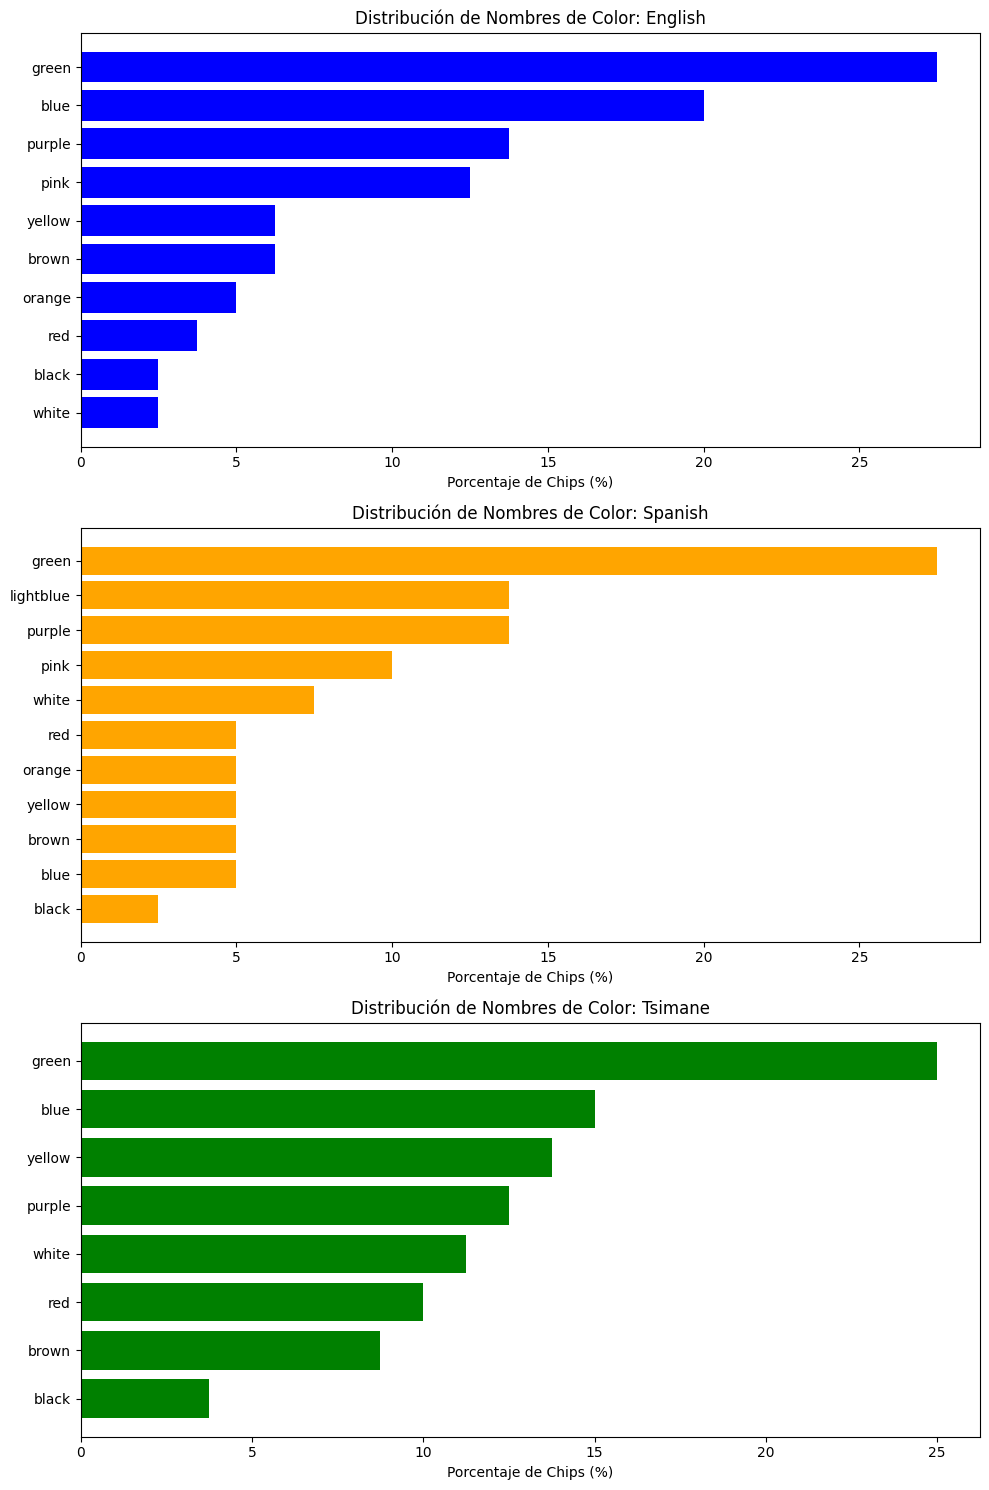

In [8]:
# Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
idiomas = [(df_english, 'English', 'blue'), (df_spanish, 'Spanish', 'orange'), (df_tsimane, 'Tsimane', 'green')]

for i, (data, nombre, color_bar) in enumerate(idiomas):
    axes[i].barh(data['color'], data['percentage'], color=color_bar)
    axes[i].set_title(f'Distribución de Nombres de Color: {nombre}')
    axes[i].set_xlabel('Porcentaje de Chips (%)')
    axes[i].invert_yaxis() # Para que el color más común esté arriba

plt.tight_layout()
plt.show()

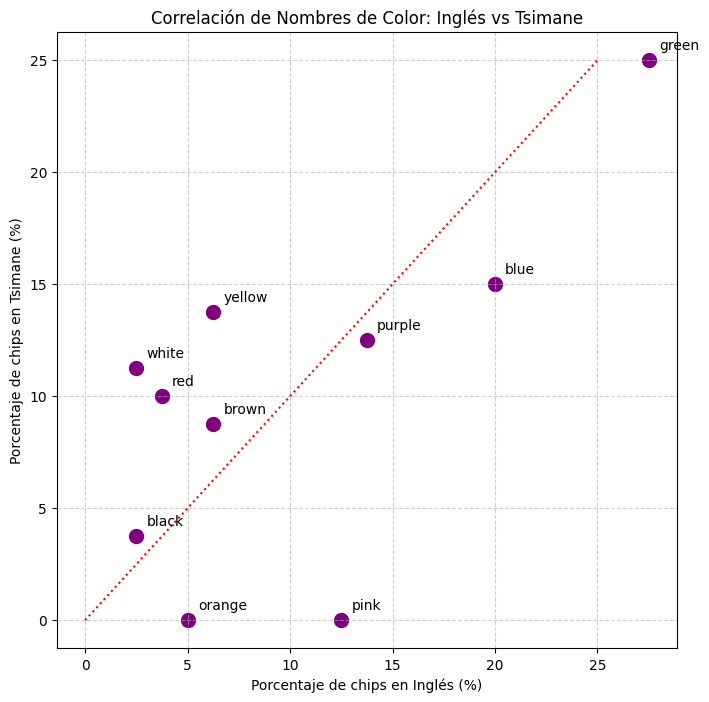

In [9]:
# Is there a correlation between languages? Create scatter plots.
# Unimos los datos para comparar Inglés vs Tsimane'
# Usamos 'outer' por si un idioma tiene un nombre de color que el otro no usó
comparativa = df_english.merge(df_tsimane, on='color', how='outer', suffixes=('_eng', '_tsi')).fillna(0)

plt.figure(figsize=(8, 8))
plt.scatter(comparativa['percentage_eng'], comparativa['percentage_tsi'], color='purple', s=100)

# Añadimos etiquetas a cada punto
for i, row in comparativa.iterrows():
    plt.text(row['percentage_eng']+0.5, row['percentage_tsi']+0.5, row['color'])

plt.title('Correlación de Nombres de Color: Inglés vs Tsimane')
plt.xlabel('Porcentaje de chips en Inglés (%)')
plt.ylabel('Porcentaje de chips en Tsimane (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot([0, 25], [0, 25], color='red', linestyle=':') # Línea de identidad (correlación perfecta)

plt.show()